<a href="https://colab.research.google.com/github/sudeeptam/Doctoral-Thesis-codes/blob/main/Thesis_Codes_04_Strengthening_Mechanisms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

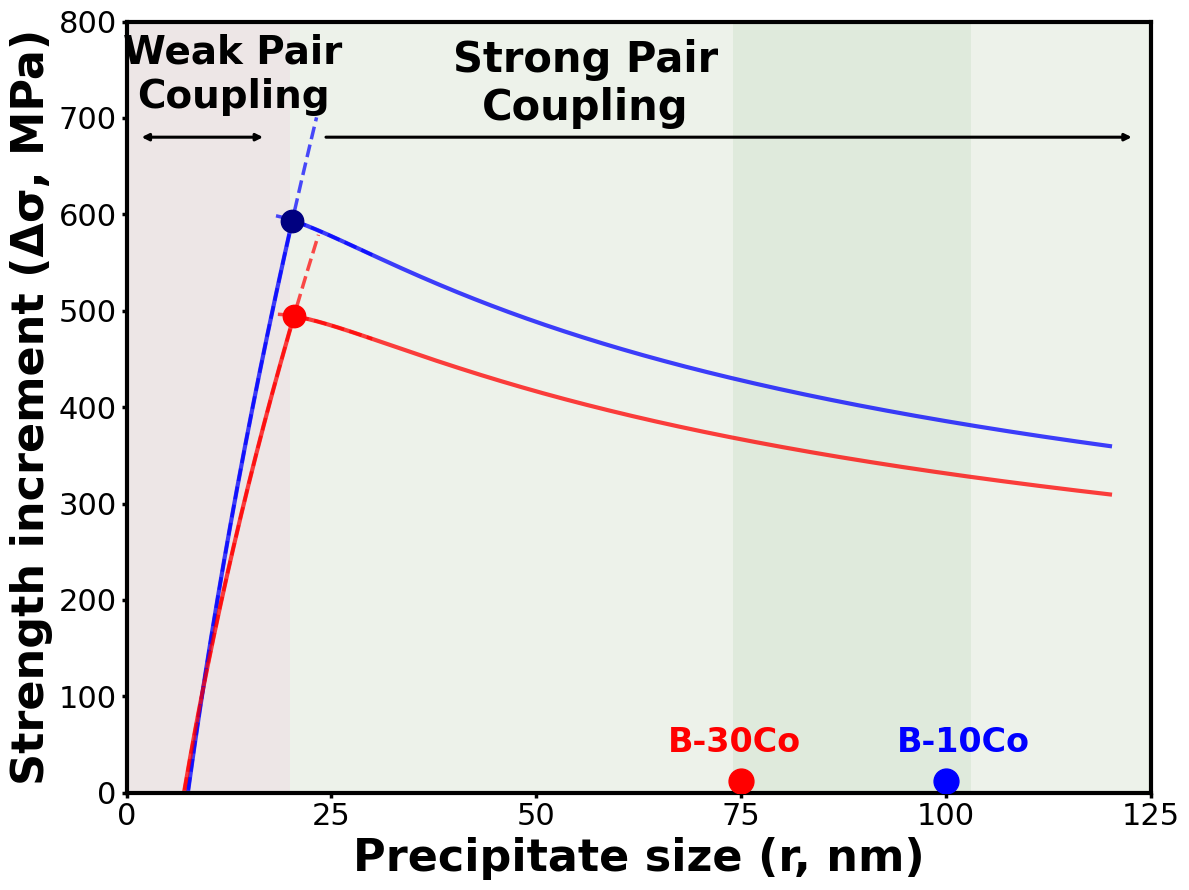

B-10Co crossover with M: r ≈ 20.20 nm, Δσ ≈ 593.0 MPa
B-30Co crossover with M: r ≈ 20.43 nm, Δσ ≈ 494.3 MPa


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

# Load Candara if available
try:
    font_path = "/mnt/data/Candara.ttf"
    candara = fm.FontProperties(fname=font_path)
    plt.rcParams["font.family"] = candara.get_name()
except Exception:
    candara = None

G = 81e9
b = 0.25e-9
w = 1.0
M = 3.06

phi_b10 = 0.753
phi_b30 = 0.635
gamma_b10 = 0.20
gamma_b30 = 0.18

r_nm = np.linspace(5, 120, 1000)
r_m = r_nm * 1e-9

def tau_strong(r, phi, gamma_apb, G=G, b=b, w=w):
    term = (2 * np.pi * r * gamma_apb) / (w * G * b**2)
    val = 0.18 * (G * b / r) * (phi**0.5) * w * (np.sqrt(term) - 1)
    return val

def tau_weak(r, phi, gamma_apb, G=G, b=b):
    term = (8 * gamma_apb * r * phi) / (np.pi * G * b**2)
    val = (gamma_apb / (2 * b)) * (np.sqrt(term) - phi)
    return val

def compute_curves(phi, gamma_apb):
    strong = M * tau_strong(r_m, phi, gamma_apb) / 1e6
    weak = M * tau_weak(r_m, phi, gamma_apb) / 1e6
    strong = np.where(strong > 0, strong, np.nan)
    weak = np.where(weak > 0, weak, np.nan)
    eff = np.where(np.isfinite(strong) & np.isfinite(weak), np.minimum(strong, weak), np.nan)
    diff = np.abs(strong - weak)
    idx = np.nanargmin(diff)
    return strong, weak, eff, r_nm[idx], np.nanmean([strong[idx], weak[idx]])

strong_b10, weak_b10, eff_b10, rc_b10, tc_b10 = compute_curves(phi_b10, gamma_b10)
strong_b30, weak_b30, eff_b30, rc_b30, tc_b30 = compute_curves(phi_b30, gamma_b30)

fig, ax = plt.subplots(figsize=(12, 9))

ax.axvspan(0, 20, color="#d8c9c9", alpha=0.45, lw=0)
ax.axvspan(20, 125, color="#dfe8da", alpha=0.55, lw=0)
ax.axvspan(74, 103, color="#cfe2cd", alpha=0.45, lw=0)

ax.plot(r_nm, eff_b10, color="blue", lw=3, alpha=0.75)
ax.plot(r_nm, eff_b30, color="red", lw=3, alpha=0.75)

mask_w_b10 = (r_nm >= 6) & (r_nm <= rc_b10 + 3)
mask_s_b10 = (r_nm >= rc_b10 - 2) & (r_nm <= 30)
mask_w_b30 = (r_nm >= 6) & (r_nm <= rc_b30 + 3)
mask_s_b30 = (r_nm >= rc_b30 - 2) & (r_nm <= 30)

ax.plot(r_nm[mask_w_b10], weak_b10[mask_w_b10], ls="--", lw=2.5, color="blue", alpha=0.7)
ax.plot(r_nm[mask_s_b10], strong_b10[mask_s_b10], ls="--", lw=2.5, color="blue", alpha=0.7)
ax.plot(r_nm[mask_w_b30], weak_b30[mask_w_b30], ls="--", lw=2.5, color="red", alpha=0.7)
ax.plot(r_nm[mask_s_b30], strong_b30[mask_s_b30], ls="--", lw=2.5, color="red", alpha=0.7)

ax.scatter(rc_b10, tc_b10, s=260, color="navy", zorder=5)
ax.scatter(rc_b30, tc_b30, s=260, color="red", zorder=5)

ax.scatter(75, 12, s=320, color="red", zorder=6)
ax.scatter(100, 12, s=320, color="blue", zorder=6)

ax.text(66, 42, "B-30Co", color="red", fontsize=24, fontweight="bold")
ax.text(94, 42, "B-10Co", color="blue", fontsize=24, fontweight="bold")

ax.text(13, 745, "Weak Pair\nCoupling", ha="center", va="center", fontsize=28, fontweight="bold")
ax.text(56, 735, "Strong Pair\nCoupling", ha="center", va="center", fontsize=30, fontweight="bold")

ax.annotate("", xy=(17, 680), xytext=(1.5, 680),
            arrowprops=dict(arrowstyle="<|-|>", lw=2.2, color="black"))
ax.annotate("", xy=(123, 680), xytext=(24, 680),
            arrowprops=dict(arrowstyle="-|>", lw=2.2, color="black"))

ax.set_xlim(0, 125)
ax.set_ylim(0, 800)
ax.set_xlabel("Precipitate size (r, nm)", fontsize=32, fontweight="bold")
ax.set_ylabel("Strength increment (Δσ, MPa)", fontsize=32, fontweight="bold")
ax.set_xticks([0, 25, 50, 75, 100, 125])
ax.set_yticks(np.arange(0, 801, 100))
ax.tick_params(axis="both", labelsize=22, width=2.5)
for spine in ax.spines.values():
    spine.set_linewidth(3)
ax.grid(False)

plt.tight_layout()
plt.show()

print(f"B-10Co crossover with M: r ≈ {rc_b10:.2f} nm, Δσ ≈ {tc_b10:.1f} MPa")
print(f"B-30Co crossover with M: r ≈ {rc_b30:.2f} nm, Δσ ≈ {tc_b30:.1f} MPa")